Import Dependencies

In [24]:
from pydantic import BaseModel

from langsmith import traceable, get_current_run_tree

import instructor

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.types import Send

from langchain_core.messages import SystemMessage
from IPython.display import Image, display

from typing import Literal, Dict, Any, Annotated, List
from operator import add

import random
import openai
import pandas as pd

from jinja2 import Template

from qdrant_client import QdrantClient
from qdrant_client import models
from qdrant_client.models import VectorParams, Distance, SparseVectorParams, Modifier, PayloadSchemaType, PointStruct, Document, Prefetch, FusionQuery


In [25]:
def get_embedding(text, model="text-embedding-3-small"):
    response = openai.embeddings.create(
        input=text,
        model=model
    )

    return response.data[0].embedding


def retrieve_data(query, qdrant_client, k=5, hybrid=True):

    query_embedding = get_embedding(query)

    if hybrid:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            prefetch=[
                Prefetch(
                    query=query_embedding,
                    using="text-embedding-3-small",
                    limit=20
                ),
                Prefetch(
                    query=Document(
                        text=query,
                        model="qdrant/bm25"
                    ),
                    using="bm25",
                    limit=20
                )
            ],
            query=models.RrfQuery(rrf=models.Rrf(weights=[3,1])),
            limit=k
        )
    else:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            query=query_embedding,
            using="text-embedding-3-small",
            limit=k
        )

    retrieved_context_ids = []
    retrieved_context = []
    similarity_scores = []
    retrieved_context_ratings = []

    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retrieved_context.append(result.payload["preprocessed_description"])
        similarity_scores.append(result.score)
        retrieved_context_ratings.append(result.payload["average_rating"])

    return {
        "retrieved_context_ids": retrieved_context_ids,
        "retrieved_context": retrieved_context,
        "similarity_scores": similarity_scores,
        "retrieved_context_ratings": retrieved_context_ratings
    }


def process_context(context):

    formatted_context = ""

    for id, chunk, rating in zip(context["retrieved_context_ids"], context["retrieved_context"], context["retrieved_context_ratings"]):
        formatted_context += f"- ID: {id}, rating: {rating}, description: {chunk}\n"

    return formatted_context

In [26]:
qdrant_client = QdrantClient(url="http://localhost:6333")

In [27]:
def get_embedding(text, model="text-embedding-3-small"):
    response = openai.embeddings.create(
        input=text,
        model=model
    )

    return response.data[0].embedding

In [28]:
def retrieve_data(query, qdrant_client, k=5, hybrid=True):

    query_embedding = get_embedding(query)

    if hybrid:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            prefetch=[
                Prefetch(
                    query=query_embedding,
                    using="text-embedding-3-small",
                    limit=20
                ),
                Prefetch(
                    query=Document(
                        text=query,
                        model="qdrant/bm25"
                    ),
                    using="bm25",
                    limit=20
                )
            ],
            query=models.RrfQuery(rrf=models.Rrf(weights=[3,1])),
            limit=k
        )
    else:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            query=query_embedding,
            using="text-embedding-3-small",
            limit=k
        )

    retrieved_context_ids = []
    retrieved_context = []
    similarity_scores = []
    retrieved_context_ratings = []

    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retrieved_context.append(result.payload["preprocessed_description"])
        similarity_scores.append(result.score)
        retrieved_context_ratings.append(result.payload["average_rating"])

    return {
        "retrieved_context_ids": retrieved_context_ids,
        "retrieved_context": retrieved_context,
        "similarity_scores": similarity_scores,
        "retrieved_context_ratings": retrieved_context_ratings
    }

In [29]:
query = "Can I get a tablet?"

In [30]:
answer = retrieve_data(query, qdrant_client, k=10)

In [31]:
answer

{'retrieved_context_ids': ['B0B7QL4FMN',
  'B0C4KCQB19',
  'B09MKYBJT6',
  'B07FMF2L6B',
  'B0BN7JTB5N',
  'B0B3QGL9C9',
  'B0BCFYCXRH',
  'B0BCDYMF5L',
  'B0C1TWNBGD',
  'B0BQ1ZVF2C'],
 'retrieved_context': ['GrandPad Senior Tablet (Renewed) with Phone Capabilities, 4G LTE, Wireless Charger, Stylus, 1 Month Premium Service Plan Included, Purchase A Plan at Activation MADE FOR SENIORS: The GrandPad is the ideal tablet & phone, all-in-one connectivity device for older adults. It has a closed network, so it keeps the older adult free of receiving any spam or robocalls. Its simple interface & easy connectivity makes it the perfect choice for families looking to stay connected in a safe & secure way. SERVICE PLAN NEEDED: 1 Month Included - A Monthly or Annual Service Plan can be purchased at Activation by calling GrandPad directly. Choose from our 599/prepaid yearly or 59/monthly (regularly 799/annual & 79/monthly) Service Plans. A Service Plan is needed to continue to have full access to 

Multi-intent Questions

In [32]:
query = "Can I get a tablet for my kid, a watch for me and a laptop for my wife?"

In [33]:
answer = retrieve_data(query, qdrant_client, k=10)

In [34]:
answer

{'retrieved_context_ids': ['B0C4KCQB19',
  'B0BQ1ZVF2C',
  'B0BFR7JRQS',
  'B0B7QL4FMN',
  'B08H1YT773',
  'B0BZ7JHGR1',
  'B07FMF2L6B',
  'B09MKYBJT6',
  'B0CCLD2KVB',
  'B0C9GFMRK2'],
 'retrieved_context': ["7inch Tablet for Kids Android 11 Tablets 3GB 32GB Parental Control Children Learning Toddler Tablet Shockproof Kickstand Case, GMS Certified, Google Tableta YouTube Netflix (Pink) ★[Best Kids-Friendly Compansion ] -With parental control mode, you can create and customize profiles for kids’accounts, hand-pick content for your kids, control screen time and ensure they are browsing safe websites. These security settings can be adjusted as kids grow with content tailored to their age. ★[A Full-feature Tablet for Kids] - This kids edition tablet has built-in a high-performance quad-core processor with stable Android 11 smooth System OS, 1024x600 IPS HD display, Wifi, Bluetooth, dual camera with flash, touch screen, 3GB RAM and 32GB ROM. You can expand the storage to 256GB of SD cards 

In [35]:
class QueryExpandResponse(BaseModel):
    statements: List[str]

In [36]:
def query_expansion_node(query) -> dict:

    prompt_template = """You are a query expansion module in a shopping assistant. Your job is to rewrite a customer's query into distinct statements for semantic product search.

## Instructions

- Expand the question into 1-5 concise statements.
- Each statement should capture a separate product or attribute from the query.
- Use natural product-description language.
- Do not produce multiple statements that express the same intent.

## Examples

Question: "Can I get earphones for me and a waterproof speaker?"
Statements:
- "Personal earphones"
- "Waterproof speaker"

Question: "I need a warm winter jacket for hiking"
Statements:
- "Insulated winter jacket"
- "Hiking outerwear for cold weather"

Question: "Do you have any toys?"
Statements:
- "Toys"

<question>
{{ query }}
</question>
"""

    template = Template(prompt_template)

    prompt = template.render(
        query=query
    )

    client = instructor.from_provider(
        "openai/gpt-5.4-nano",
        mode=instructor.Mode.RESPONSES_TOOLS
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt}
        ],
        reasoning={"effort": "none"},
        response_model=QueryExpandResponse
    )

    return {
        "queries": response.statements
    }

In [37]:
answer = query_expansion_node(query)

In [38]:
answer

{'queries': ['Tablet for a kid',
  'Smartwatch for personal use',
  'Laptop for a wife']}

LangGraph

Query Expansion (Sequential Execution)

In [39]:
class State(BaseModel):
    expanded_query: List[str] = []
    retrieved_context: Annotated[List[str], add] = []
    initial_query: str = ""
    answer: str = ""

Query Expansion / Rewriting Node

In [40]:
class QueryExpandResponse(BaseModel):
    statements: List[str]

In [41]:
@traceable(
    name="query_expansion",
    run_type="llm",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "gpt-5.4-mini"
    }
)
def query_expansion_node(state: State) -> dict:

    prompt_template = """You are a query expansion module in a shopping assistant. Your job is to rewrite a customer's query into distinct statements for semantic product search.

## Instructions

- Expand the question into 1-5 concise statements.
- Each statement should capture a separate product or attribute from the query.
- Use natural product-description language.
- Do not produce multiple statements that express the same intent.

## Examples

Question: "Can I get earphones for me and a waterproof speaker?"
Statements:
- "Personal earphones"
- "Waterproof speaker"

Question: "I need a warm winter jacket for hiking"
Statements:
- "Insulated winter jacket"
- "Hiking outerwear for cold weather"

Question: "Do you have any toys?"
Statements:
- "Toys"

<question>
{{ query }}
</question>
"""

    template = Template(prompt_template)

    prompt = template.render(
        query=state.initial_query
    )

    client = instructor.from_provider(
        "openai/gpt-5.4-mini",
        mode=instructor.Mode.RESPONSES_TOOLS
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt}
        ],
        reasoning={"effort": "none"},
        response_model=QueryExpandResponse
    )

    return {
        "expanded_query": response.statements
    }

Retriever Node

In [42]:
@traceable(
    name="embed_query",
    run_type="embedding",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "text-embedding-3-small"
    }
)
def get_embedding(text, model="text-embedding-3-small"):
    response = openai.embeddings.create(
        input=text,
        model=model
    )

    current_run = get_current_run_tree()
    if current_run:
        current_run.metadata["usage_metadata"] = {
            "input_tokens": response.usage.prompt_tokens,
            "total_tokens": response.usage.total_tokens,
        }

    return response.data[0].embedding


@traceable(
    name="retrieve_data",
    run_type="retriever"
)
def retrieve_data(query, qdrant_client, k=5, hybrid=True):

    query_embedding = get_embedding(query)

    if hybrid:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            prefetch=[
                Prefetch(
                    query=query_embedding,
                    using="text-embedding-3-small",
                    limit=20
                ),
                Prefetch(
                    query=Document(
                        text=query,
                        model="qdrant/bm25"
                    ),
                    using="bm25",
                    limit=20
                )
            ],
            query=models.RrfQuery(rrf=models.Rrf(weights=[3,1])),
            limit=k
        )
    else:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            query=query_embedding,
            using="text-embedding-3-small",
            limit=k
        )

    retrieved_context_ids = []
    retrieved_context = []
    similarity_scores = []
    retrieved_context_ratings = []

    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retrieved_context.append(result.payload["preprocessed_description"])
        similarity_scores.append(result.score)
        retrieved_context_ratings.append(result.payload["average_rating"])

    formatted_context = ""

    for id, chunk, rating in zip(retrieved_context_ids, retrieved_context, retrieved_context_ratings):
        formatted_context += f"- ID: {id}, rating: {rating}, description: {chunk}\n"

    return formatted_context

@traceable(
    name="retriever_node",
    run_type="retriever"
)
def retriever_node(state: State) -> dict:

    qdrant_client = QdrantClient(url="http://localhost:6333")

    retrieved_context = []

    for query in state.expanded_query:
        retrieved_context.append(retrieve_data(query, qdrant_client, k=5))

    return {
        "retrieved_context": retrieved_context
    }

Aggregator Node

In [43]:
class AggregatorResponse(BaseModel):
    answer: str

In [44]:
@traceable(
    name="generate_answer",
    run_type="llm",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "gpt-5.4-mini"
    }
)
def aggregator_node(state: State) -> dict:

    preprocessed_context = "\n".join(state.retrieved_context)

    prompt_template = """You are a shopping assistant that can answer questions about the products in stock.

You will be given a question and a list of context.

### Instructions

- You need to answer the question based on the provided context only.
- Never use word context and refer to it as the available products.
- The answer to the question should contain detailed information about the product and returned with detailed specification in bullet points.

### Context

{{ preprocessed_context }}

### Question

{{ question }}
"""

    template = Template(prompt_template)

    prompt = template.render(
        preprocessed_context=preprocessed_context,
        question=state.initial_query
    )

    client = instructor.from_provider(
        "openai/gpt-5.4-mini",
        mode=instructor.Mode.RESPONSES_TOOLS
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt}
        ],
        reasoning={"effort": "none"},
        response_model=AggregatorResponse
    )

    return {
        "answer": response.answer
    }

In [45]:
workflow = StateGraph(State)

workflow.add_node("query_expansion_node", query_expansion_node)
workflow.add_node("retriever_node", retriever_node)
workflow.add_node("aggregator_node", aggregator_node)

workflow.add_edge(START, "query_expansion_node")
workflow.add_edge("query_expansion_node", "retriever_node")
workflow.add_edge("retriever_node", "aggregator_node")
workflow.add_edge("aggregator_node", END)

graph = workflow.compile()

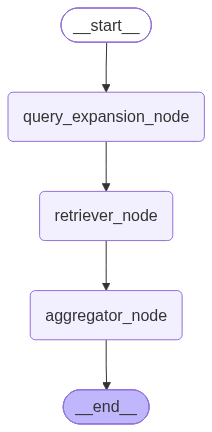

In [46]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [47]:
query = "Can I get a tablet for my kid, a watch for me and a laptop for my wife?"

In [48]:
initial_state = {
    "initial_query": query
}

In [49]:
result = graph.invoke(initial_state)

In [50]:
result

{'expanded_query': ['Tablet for a child',
  'Watch for adult use',
  'Laptop for wife'],
 'retrieved_context': ['- ID: B0C4KCQB19, rating: 3.7, description: 7inch Tablet for Kids Android 11 Tablets 3GB 32GB Parental Control Children Learning Toddler Tablet Shockproof Kickstand Case, GMS Certified, Google Tableta YouTube Netflix (Pink) ★[Best Kids-Friendly Compansion ] -With parental control mode, you can create and customize profiles for kids’accounts, hand-pick content for your kids, control screen time and ensure they are browsing safe websites. These security settings can be adjusted as kids grow with content tailored to their age. ★[A Full-feature Tablet for Kids] - This kids edition tablet has built-in a high-performance quad-core processor with stable Android 11 smooth System OS, 1024x600 IPS HD display, Wifi, Bluetooth, dual camera with flash, touch screen, 3GB RAM and 32GB ROM. You can expand the storage to 256GB of SD cards for storing photos, music, videos. A more stable Wifi

In [51]:
print(result["answer"])

Yes — based on the available products, I can suggest options for all three:

- Tablet for your kid:
  - ID: B0C4KCQB19
  - 7-inch kids tablet
  - Android 11, 3GB RAM, 32GB ROM
  - Parental control mode for safe browsing and screen-time management
  - 1024x600 IPS HD display
  - Quad-core processor, Wi‑Fi, Bluetooth, dual camera with flash
  - Storage expandable up to 256GB with SD card
  - 3000mAh battery
  - Includes kid-proof shockproof case with kickstand
  - GMS certified and supports Google Play, YouTube, and Netflix

- Watch for you:
  - I do not see a properly described watch in the available products
  - There is an item listed as a smart watch, but its description is incomplete: ID B09VC1634J
  - Because the details are not provided, I can’t confirm its features or suitability

- Laptop for your wife:
  - ID: B09ZQTHHPZ
  - 15.6-inch laptop tote bag for women
  - Waterproof PU leather, large capacity, professional briefcase style
  - Fits up to a 15.6-inch laptop
  - Multiple 

Query Expansion (Parallel Execution)

In [52]:
class State(BaseModel):
    expanded_query: List[str] = []
    retrieved_context: Annotated[List[str], add] = []
    initial_query: str = ""
    answer: str = ""
    query: str = ""
    k: int = 10

Query Expansion / Rewriting Node

In [53]:
class QueryExpandResponse(BaseModel):
    statements: List[str]

In [54]:
@traceable(
    name="query_expansion",
    run_type="llm",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "gpt-5.4-mini"
    }
)
def query_expansion_node(state: State) -> dict:

    prompt_template = """You are a query expansion module in a shopping assistant. Your job is to rewrite a customer's query into distinct statements for semantic product search.

## Instructions

- Expand the question into 1-5 concise statements.
- Each statement should capture a separate product or attribute from the query.
- Use natural product-description language.
- Do not produce multiple statements that express the same intent.

## Examples

Question: "Can I get earphones for me and a waterproof speaker?"
Statements:
- "Personal earphones"
- "Waterproof speaker"

Question: "I need a warm winter jacket for hiking"
Statements:
- "Insulated winter jacket"
- "Hiking outerwear for cold weather"

Question: "Do you have any toys?"
Statements:
- "Toys"

<question>
{{ query }}
</question>
"""

    template = Template(prompt_template)

    prompt = template.render(
        query=state.initial_query
    )

    client = instructor.from_provider(
        "openai/gpt-5.4-mini",
        mode=instructor.Mode.RESPONSES_TOOLS
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt}
        ],
        reasoning={"effort": "none"},
        response_model=QueryExpandResponse
    )

    return {
        "expanded_query": response.statements
    }

In [55]:
def query_expand_conditional_edges(state: State) -> dict:

    send_messages = []

    for query in state.expanded_query:
        send_messages.append(
            Send(
                "retriever_node",
                {
                    "query": query,
                    "k": state.k
                }
            )
        )

    return send_messages

Retriever Node

In [56]:
@traceable(
    name="embed_query",
    run_type="embedding",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "text-embedding-3-small"
    }
)
def get_embedding(text, model="text-embedding-3-small"):
    response = openai.embeddings.create(
        input=text,
        model=model
    )

    current_run = get_current_run_tree()
    if current_run:
        current_run.metadata["usage_metadata"] = {
            "input_tokens": response.usage.prompt_tokens,
            "total_tokens": response.usage.total_tokens,
        }

    return response.data[0].embedding


@traceable(
    name="retrieve_data",
    run_type="retriever"
)
def retriever_node(state: State) -> dict:

    hybrid = True

    qdrant_client = QdrantClient(url="http://localhost:6333")

    query_embedding = get_embedding(state["query"])

    if hybrid:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            prefetch=[
                Prefetch(
                    query=query_embedding,
                    using="text-embedding-3-small",
                    limit=20
                ),
                Prefetch(
                    query=Document(
                        text=query,
                        model="qdrant/bm25"
                    ),
                    using="bm25",
                    limit=20
                )
            ],
            query=models.RrfQuery(rrf=models.Rrf(weights=[3,1])),
            limit=state["k"]
        )
    else:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            query=query_embedding,
            using="text-embedding-3-small",
            limit=state["k"]
        )

    retrieved_context_ids = []
    retrieved_context = []
    similarity_scores = []
    retrieved_context_ratings = []

    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retrieved_context.append(result.payload["preprocessed_description"])
        similarity_scores.append(result.score)
        retrieved_context_ratings.append(result.payload["average_rating"])

    formatted_context = ""

    for id, chunk, rating in zip(retrieved_context_ids, retrieved_context, retrieved_context_ratings):
        formatted_context += f"- ID: {id}, rating: {rating}, description: {chunk}\n"

    return {
        "retrieved_context": [formatted_context]
    }

Aggregator Node

In [57]:
class AggregatorResponse(BaseModel):
    answer: str

In [58]:
@traceable(
    name="generate_answer",
    run_type="llm",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "gpt-5.4-mini"
    }
)
def aggregator_node(state: State) -> dict:

    preprocessed_context = "\n".join(state.retrieved_context)

    prompt_template = """You are a shopping assistant that can answer questions about the products in stock.

You will be given a question and a list of context.

### Instructions

- You need to answer the question based on the provided context only.
- Never use word context and refer to it as the available products.
- The answer to the question should contain detailed information about the product and returned with detailed specification in bullet points.

### Context

{{ preprocessed_context }}

### Question

{{ question }}
"""

    template = Template(prompt_template)

    prompt = template.render(
        preprocessed_context=preprocessed_context,
        question=state.initial_query
    )

    client = instructor.from_provider(
        "openai/gpt-5.4-mini",
        mode=instructor.Mode.RESPONSES_TOOLS
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt}
        ],
        reasoning={"effort": "none"},
        response_model=AggregatorResponse
    )

    return {
        "answer": response.answer
    }

In [59]:
workflow = StateGraph(State)

workflow.add_node("query_expansion_node", query_expansion_node)
workflow.add_node("retriever_node", retriever_node)
workflow.add_node("aggregator_node", aggregator_node)

workflow.add_conditional_edges(
    "query_expansion_node",
    query_expand_conditional_edges
)

workflow.add_edge(START, "query_expansion_node")
workflow.add_edge("retriever_node", "aggregator_node")
workflow.add_edge("aggregator_node", END)

graph = workflow.compile()

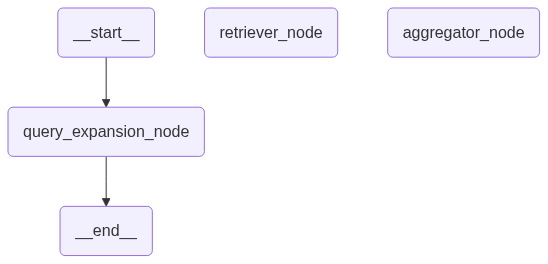

In [60]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [61]:
query = "Can I get a tablet for my kid, a watch for me and a laptop for my wife?"

In [62]:
initial_state = {
    "initial_query": query
}

In [63]:
result = graph.invoke(initial_state)

In [64]:
result

{'expanded_query': ["Kids' tablet",
  'Watch for personal use',
  'Laptop for wife'],
 'retrieved_context': ['- ID: B0C4KCQB19, rating: 3.7, description: 7inch Tablet for Kids Android 11 Tablets 3GB 32GB Parental Control Children Learning Toddler Tablet Shockproof Kickstand Case, GMS Certified, Google Tableta YouTube Netflix (Pink) ★[Best Kids-Friendly Compansion ] -With parental control mode, you can create and customize profiles for kids’accounts, hand-pick content for your kids, control screen time and ensure they are browsing safe websites. These security settings can be adjusted as kids grow with content tailored to their age. ★[A Full-feature Tablet for Kids] - This kids edition tablet has built-in a high-performance quad-core processor with stable Android 11 smooth System OS, 1024x600 IPS HD display, Wifi, Bluetooth, dual camera with flash, touch screen, 3GB RAM and 32GB ROM. You can expand the storage to 256GB of SD cards for storing photos, music, videos. A more stable Wifi mo

In [65]:
print(result["answer"])

Yes — based on the available products, I can suggest a kid-friendly tablet and laptops for your wife, but I do not see a watch specifically for you. I’ve listed the closest matching options below:

- **For your kid: 7inch Tablet for Kids (ID: B0C4KCQB19)**
  - Rating: **3.7**
  - **Android 11** kids tablet with **parental control mode** for managing profiles, content, and screen time
  - **7-inch** display with **1024x600 IPS HD** screen
  - **3GB RAM / 32GB ROM**, expandable up to **256GB** with SD card
  - **Quad-core processor**, **WiFi**, **Bluetooth**, **dual camera with flash**, and touchscreen
  - Comes with **pre-installed kids apps/games** and access to Google Play Store
  - Includes an **exclusive kid-proof shockproof case** with a **built-in kickstand**
  - **3000mAh battery**
  - GMS certified and includes YouTube/Netflix support in the listing

- **For your wife: Laptop options**
  - **ASUS VivoBook 15 R565 Thin and Light Laptop (ID: B0BKRMDCBF)**
    - Rating: **4.4**
   